<a href="https://colab.research.google.com/github/bhargav-chataut/world_model_2018/blob/main/VAE_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0: Mount Drive & Pull from Github

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!git clone https://github.com/bhargav-chataut/world_model_2018.git
%cd /content/world_model_2018

Cloning into 'world_model_2018'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 117 (delta 64), reused 84 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 21.06 KiB | 7.02 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/world_model_2018


In [3]:
!git pull

Already up to date.


In [4]:
!pip install -q swig "gymnasium[box2d]" pillow numpy
import importlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 71.4 MB/s eta 0:00:00


## 1: Collect Episodes
Using multiple processes at once to speed up the process

In [5]:
import importlib
import collect

importlib.reload(collect)

collect.collect_dataset(
    num_episodes=100,
    output_dir="/content/drive/MyDrive/World_Model_2018/data",
    workers=2
)


Episode 0: 1000 frames
Episode 1: 1000 frames
Episode 2: 1000 frames
Episode 3: 1000 frames
Episode 4: 1000 frames
Episode 5: 1000 frames
Episode 6: 1000 frames
Episode 7: 1000 frames
Episode 8: 1000 frames
Episode 9: 1000 frames
Episode 10: 1000 frames
Episode 11: 1000 frames
Episode 12: 1000 frames
Episode 13: 1000 frames
Episode 14: 1000 frames
Episode 15: 1000 frames
Episode 16: 1000 frames
Episode 17: 1000 frames
Episode 18: 1000 frames
Episode 19: 1000 frames
Episode 20: 1000 frames
Episode 21: 1000 frames
Episode 22: 1000 frames
Episode 23: 1000 frames
Episode 24: 1000 frames
Episode 25: 1000 frames
Episode 26: 1000 frames
Episode 27: 1000 frames
Episode 28: 1000 frames
Episode 29: 1000 frames
Episode 30: 1000 frames
Episode 31: 1000 frames
Episode 32: 1000 frames
Episode 33: 1000 frames
Episode 34: 1000 frames
Episode 35: 1000 frames
Episode 36: 1000 frames
Episode 37: 1000 frames
Episode 38: 1000 frames
Episode 39: 1000 frames
Episode 40: 1000 frames
Episode 41: 1000 frames
Ep

###### Visualize episodes

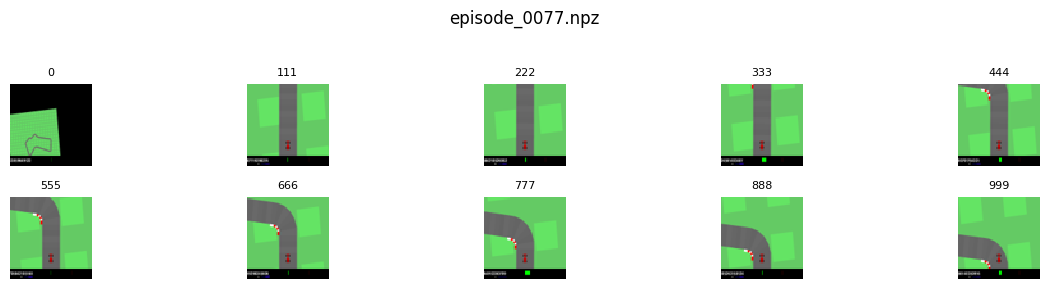

Selected frames: [  0 111 222 333 444 555 666 777 888 999]


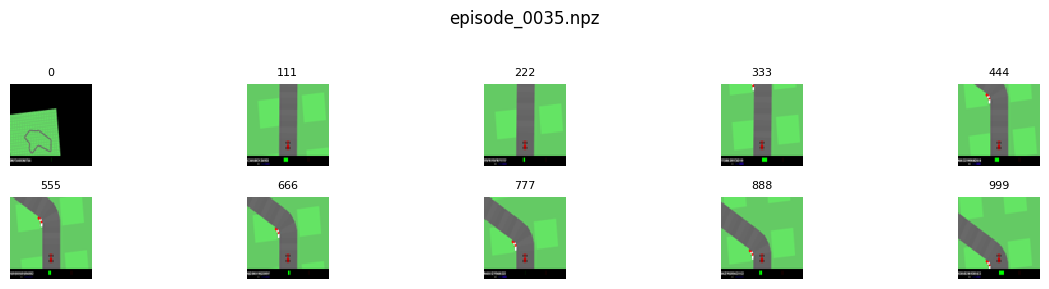

Selected frames: [  0 111 222 333 444 555 666 777 888 999]


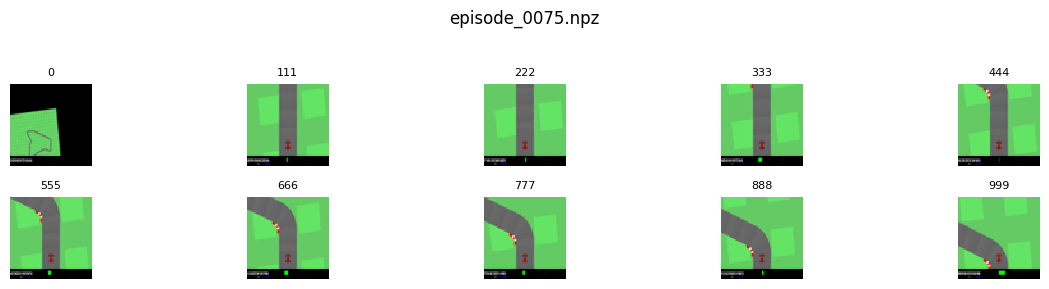

Selected frames: [  0 111 222 333 444 555 666 777 888 999]


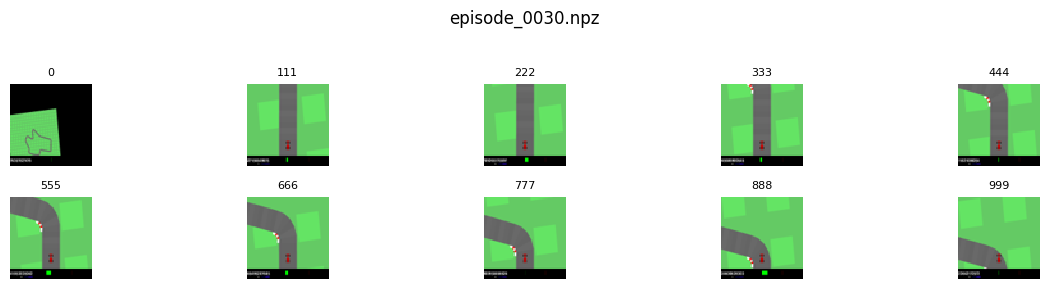

Selected frames: [  0 111 222 333 444 555 666 777 888 999]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

data_dir = Path("/content/drive/MyDrive/World_Model_2018/data")

episode_files = list(data_dir.glob("episode_*.npz"))

# Pick 4 random episodes
chosen = random.sample(episode_files, 4)

for file in chosen:
    data = np.load(file)
    frames = data["frames"]

    # Select 20 frames spread across the episode
    indices = np.linspace(
        0,
        len(frames) - 1,
        10,
        dtype=int
    )

    plt.figure(figsize=(12, 5))

    for i, idx in enumerate(indices):
        plt.subplot(4, 5, i + 1)
        plt.imshow(frames[idx], interpolation="nearest")
        plt.title(f"{idx}", fontsize=8)
        plt.axis("off")

    plt.suptitle(file.name, y=1.02)

    plt.tight_layout()
    plt.show()

    print("Selected frames:", indices)

## 2: Prepare Dataset
Combine frames from all episodes into one dataset, then split it into training and validation sets.

In [7]:
import importlib
import dataset

importlib.reload(dataset)

train_frames, val_frames = dataset.load_dataset(
    "/content/drive/MyDrive/World_Model_2018/data"
)

print("Train:", train_frames.shape)
print("Validation:", val_frames.shape)


Train: (90000, 64, 64, 3)
Validation: (10000, 64, 64, 3)


###### Check to see episodes exist



In [8]:
from pathlib import Path

data_dir = Path("/content/drive/MyDrive/World_Model_2018/data")

episode_files = list(data_dir.glob("episode_*.npz"))

print("Episodes found:", len(episode_files))

Episodes found: 100


###### Check model processes correct dimensions with dummy dataset

In [9]:
import importlib
import torch
import vae

importlib.reload(vae)

model = vae.VAE()

x = torch.randn(4, 3, 64, 64)

reconstruction, mu, log_var = model(x)

print("Input:", x.shape)
print("Reconstruction:", reconstruction.shape)
print("Mu:", mu.shape)
print("Log var:", log_var.shape)


Input: torch.Size([4, 3, 64, 64])
Reconstruction: torch.Size([4, 3, 64, 64])
Mu: torch.Size([4, 32])
Log var: torch.Size([4, 32])


## 3: Train VAE
Train a Variational Autoencoder to compress each 64x64 frame into a smaller latent representation.

In [10]:
import importlib
import train_vae

importlib.reload(train_vae)

model, val_loader, device = train_vae.train(
    data_dir="/content/drive/MyDrive/World_Model_2018/data",
    save_dir="/content/drive/MyDrive/World_Model_2018/checkpoints",
    epochs=10,
    checkpoint_path="/content/drive/MyDrive/World_Model_2018/checkpoints/vae_epoch_10.pt"
)

Device: cuda
Loaded checkpoint at epoch: 10


## 4: Visualize VAE Reconstructions

### Epoch I:

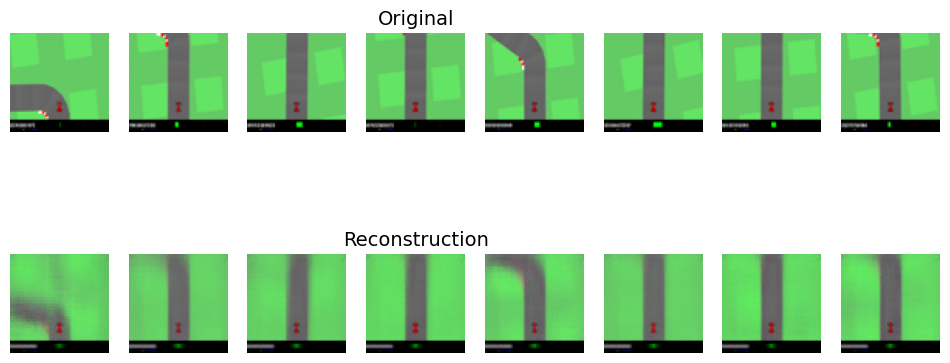

In [11]:
import importlib
import vizualize_vae

importlib.reload(vizualize_vae)

vizualize_vae.show_checkpoint_reconstructions(
    "/content/drive/MyDrive/World_Model_2018/checkpoints/vae_epoch_1.pt",
    val_loader,
    device,
    num_images=8
)


### Epoch V:

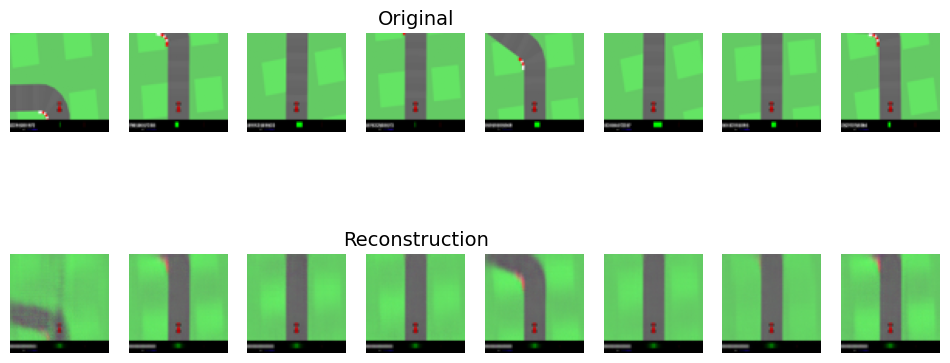

In [12]:
import importlib
import vizualize_vae

importlib.reload(vizualize_vae)

vizualize_vae.show_checkpoint_reconstructions(
    "/content/drive/MyDrive/World_Model_2018/checkpoints/vae_epoch_5.pt",
    val_loader,
    device,
    num_images=8
)


### Epoch X:

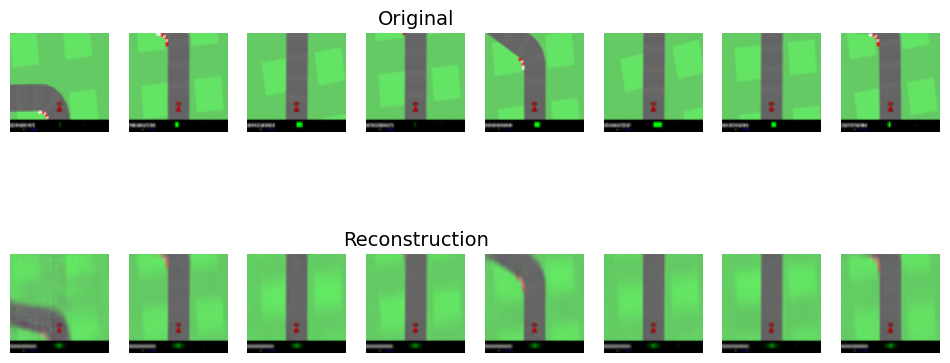

In [13]:
import importlib
import vizualize_vae

importlib.reload(vizualize_vae)

vizualize_vae.show_checkpoint_reconstructions(
    "/content/drive/MyDrive/World_Model_2018/checkpoints/vae_epoch_10.pt",
    val_loader,
    device,
    num_images=8
)


## 5: Inspecting Training History

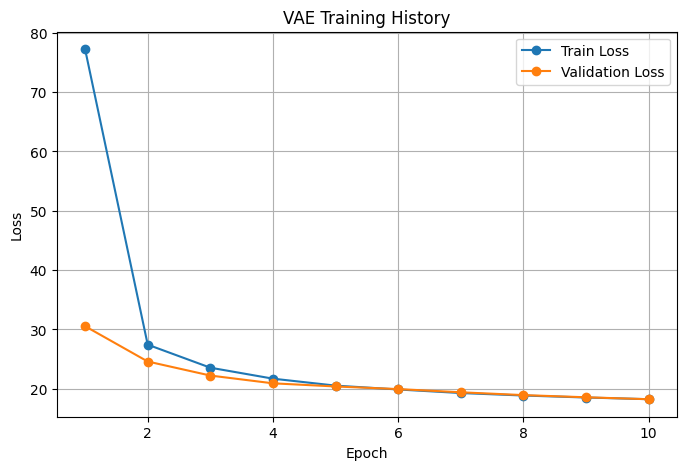

In [14]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

checkpoint_dir = Path(
    "/content/drive/MyDrive/World_Model_2018/checkpoints"
)

checkpoint_files = sorted(
    checkpoint_dir.glob("vae_epoch_*.pt"),
    key=lambda x: int(x.stem.split("_")[-1])
)

epochs = []
train_losses = []
val_losses = []

for file in checkpoint_files:
    checkpoint = torch.load(file, map_location="cpu")

    epochs.append(checkpoint["epoch"])
    train_losses.append(checkpoint["train_loss"])
    val_losses.append(checkpoint["val_loss"])

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training History")
plt.legend()
plt.grid()

plt.show()